# OpenEar: ultra-affordable maize ear phenotyping — minimal reproduction

Reproduction of: **"OpenEar: an ultra-affordable, high-throughput, and accurate maize ear phenotyping system"** (Plant Methods, 2026, doi:[10.1186/s13007-026-01504-x](https://doi.org/10.1186/s13007-026-01504-x)).

- **Author code:** https://github.com/Chimaco37/OpenEar (Apache-2.0), pinned commit `1a2a5716be13a391202f543df8b6308249d21227`
- **Weights:** Figshare [Models of OpenEar](https://doi.org/10.6084/m9.figshare.29115983) (CC BY 4.0): `Projection.pt`, `Ear.pt` (YOLOv11-seg)
- **Sample data:** Figshare [Samples for OpenEar](https://doi.org/10.6084/m9.figshare.26283013) (CC BY 4.0)

**Scope (one-video demo):** one turntable video → cylindrical projection + 6 ear frames → YOLOv11-seg inference → 10 ear/kernel traits (EL, ED, EV, EW, KN, KRN, KNpR, KT, KW, TKW) with CNN quality control. This is **not** a full-dataset benchmark, training, or verification of the paper's published accuracy.

**日本語:** 実回転テーブル動画1本から円筒投影画像と6枚の穂画像を作り、YOLOv11-segと著者提供重みで推論、10形質（穂長・穂径・穂容積・穂重・粒数・列数・列あたり粒数・粒厚・粒幅・千粒重）をCNN品質チェック付きで算出します。論文の精度検証ではなく1サンプルの最小デモです。

## 1. Runtime selection and how to run

**Recommended runtime: a Colab T4 GPU** (Runtime → Change runtime type → T4 GPU), because this workflow runs two large segmentation checkpoints. The same notebook also supports CPU, with longer inference time.

**Validated:** 2026-09-30 on Colab Standard CPU (Python 3.13.15, PyTorch 2.11.0+cpu). The T4 allocator returned Service Unavailable during this run, so CPU was selected from the supported paths. CPU is validated; GPU behavior remains unverified.

Run **Runtime → Run all**. Setup, video processing, and inference timings are printed from the actual runtime. Hardware availability and run times may vary.

**日本語:** 大きなセグメンテーションモデルを2つ使うため、ColabのT4 GPUを推奨します。同じノートブックはCPUでも動作しますが、推論時間は長くなります。

**動作確認:** 2026-09-30にColab Standard CPU（Python 3.13.15、PyTorch 2.11.0+cpu）で全コードセルを実行しました。T4の割り当てがService UnavailableだったためCPUで検証しています。CPUは検証済み、GPUは未検証です。実際のセットアップ・動画処理・推論時間は各セルに表示されます。


In [ ]:
import os, torch, platform, time

# Define the working directory before any download or extraction cell uses it.
WORK = '/content/openear'
os.makedirs(WORK, exist_ok=True)
print('python', platform.python_version())
print('torch', torch.__version__, '| CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    device = 0
else:
    print('No GPU allocated - running the CPU path (same science, slower inference).')
    device = 'cpu'

python 3.13.15
torch 2.11.0+cpu | CUDA available: False
No GPU allocated - running the CPU path (same science, slower inference).


## 2. Environment and dependencies

The author's repository pins Ultralytics 8.2.20 and Shapely 2.0.4. Colab supplied Python 3.13 during this validation, where that older Shapely pin attempted a source build and failed. This notebook therefore pins Ultralytics 8.4.158 and Shapely 2.1.2, which provide compatible Python 3.13 packages while keeping the YOLO prediction and Shapely geometry APIs used here. TensorFlow/Keras is supplied by Colab to load the author's two `.h5` quality-control models.

The install cell checks every return code and stops immediately on failure; it also verifies `ffmpeg`. No training or model conversion is performed.

**日本語:** 著者のリポジトリはUltralytics 8.2.20・Shapely 2.0.4を指定しています。検証時のColabはPython 3.13で、旧Shapelyの固定版はソースビルドに失敗しました。そのためPython 3.13対応版のUltralytics 8.4.158・Shapely 2.1.2を使用します。ここで使うYOLO推論とShapelyの幾何APIは保ちます。TensorFlow/KerasはColabの環境を使い、著者の`.h5`品質判定モデルを読み込みます。

インストール結果と`ffmpeg`の有無を検査し、失敗時は処理を停止します。学習やモデル変換は行いません。


In [ ]:
import importlib.metadata, shutil, subprocess, sys, time

t0 = time.time()
packages = ['ultralytics==8.4.158', 'shapely==2.1.2']
install = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--timeout', '120', '--retries', '3', *packages],
    text=True, capture_output=True)
if install.returncode != 0:
    print(install.stdout)
    print(install.stderr)
    raise RuntimeError(f'Package installation failed with exit code {install.returncode}.')

for package in ('ultralytics', 'shapely'):
    print(f'{package}=={importlib.metadata.version(package)}')

if shutil.which('ffmpeg') is None:
    install_ffmpeg = subprocess.run(
        ['bash', '-lc', 'apt-get -qq update && apt-get install -y -qq ffmpeg'],
        text=True, capture_output=True)
    if install_ffmpeg.returncode != 0:
        print(install_ffmpeg.stdout)
        print(install_ffmpeg.stderr)
        raise RuntimeError('ffmpeg installation failed.')
subprocess.run(['ffmpeg', '-version'], check=True, capture_output=True, text=True)
print('ffmpeg:', shutil.which('ffmpeg'))
print('setup seconds:', round(time.time() - t0, 1))


ultralytics==8.4.158
shapely==2.1.2


ffmpeg: /usr/bin/ffmpeg
setup seconds: 6.6


## 3. Download the pinned weights, calibration file, QC CNNs, and one sample video

All downloads happen here in Colab:

- `Projection.pt` (125 MB) and `Ear.pt` (125 MB): YOLOv11-seg weights, Figshare file IDs `54694049` / `54726404` (record 29115983, CC BY 4.0). We check the recorded MD5.
- Camera calibration `HQ_camera_1072_1440_mtx_dist.npz` (602 B) and the two QC CNNs `.h5` (7.2 MB each) come from the pinned author repository at commit `1a2a5716…`.
- The demo video: the samples record (26283013) is a 1.52 GB zip of 105 mp4s. Instead of downloading the whole archive we read the zip's central directory over HTTP and stream only **one member** (`24-HN-004-09.mp4`, deterministic first sorted sample) with HTTP Range requests, ≈15 MB transferred.

**日本語:** 重み2本（Figshare、MD5確認付き）、カメラ校正ファイル、QC用CNN 2本（著者リポジトリ固定コミットから）、そしてサンプル動画をダウンロードします。サンプルは1.52 GBのzipから1ファイル（約15 MB）だけをHTTP Rangeで取り出します。

### Verify the exact Figshare records through the official API

Before downloading files, this cell checks the cited public record versions and their file IDs, names, sizes, checksums, and API-returned download URLs. It makes metadata requests only; file contents are fetched in later Colab cells.

**日本語:** ダウンロード前に公式の公開APIで指定バージョンとファイルID・名称・サイズ・チェックサム・取得URLを確認します。このセルはメタデータだけを取得し、ファイル本体は後続のColabセルで取得します。

In [ ]:
import json, time, urllib.error, urllib.request
FIGSHARE_API = 'https://api.figshare.com/v2'
_last_figshare_request = 0.0

def figshare_get(url):
    global _last_figshare_request
    for attempt in range(3):
        time.sleep(max(0, 1.05 - (time.monotonic() - _last_figshare_request)))
        request = urllib.request.Request(
            url, headers={'Accept': 'application/json',
                          'User-Agent': 'OpenEar-Colab-reproduction/1.0'})
        _last_figshare_request = time.monotonic()
        try:
            with urllib.request.urlopen(request, timeout=45) as response:
                if response.status != 200:
                    raise RuntimeError(f'Unexpected Figshare API status: {response.status}')
                return json.load(response)
        except urllib.error.HTTPError as error:
            if (error.code != 429 and error.code < 500) or attempt == 2:
                raise
            try:
                delay = float(error.headers.get('Retry-After', 2 ** attempt))
            except ValueError:
                delay = 2 ** attempt
            time.sleep(min(max(delay, 1.05), 30))

def figshare_version(article_id, version, title_fragment):
    versions = figshare_get(f'{FIGSHARE_API}/articles/{article_id}/versions')
    available = {int(item['version']) for item in versions}
    if version not in available:
        raise ValueError(f'Figshare article {article_id} has no version {version}')
    record = figshare_get(f'{FIGSHARE_API}/articles/{article_id}/versions/{version}')
    if int(record.get('id', -1)) != article_id or int(record.get('version', -1)) != version:
        raise ValueError(f'Figshare record identity/version mismatch: {article_id} v{version}')
    if title_fragment.lower() not in record.get('title', '').lower():
        raise ValueError(f'Unexpected Figshare record title: {record.get("title")}')
    print(f'Record {article_id} v{version}: {record["title"]}')
    return record

def figshare_file(record, file_id, name, size, checksum):
    item = next((f for f in record.get('files', []) if str(f.get('id')) == str(file_id)), None)
    if item is None or item.get('name') != name or int(item.get('size', -1)) != size:
        raise ValueError(f'Figshare file metadata mismatch: {file_id} {name}')
    api_md5 = (item.get('computed_md5') or item.get('supplied_md5') or item.get('md5') or '').lower()
    if api_md5 != checksum or not item.get('download_url'):
        raise ValueError(f'Figshare checksum or public download URL mismatch: {name}')
    print(f'File {file_id}: {name}, {size:,} bytes; API MD5 matches')
    return {'name': name, 'size': size, 'md5': checksum, 'download_url': item['download_url']}

models_record = figshare_version(29115983, 3, 'Models of OpenEar')
samples_record = figshare_version(26283013, 3, 'Samples for OpenEar')
FIGSHARE_FILES = {
    '54694049': figshare_file(models_record, 54694049, 'Projection.pt', 124878682,
                              '702e8b60521238b28055c04aebee0a0b'),
    '54726404': figshare_file(models_record, 54726404, 'Ear.pt', 124873967,
                              'f58933b95a2615dcbb6814f59715743e'),
}
sample_zip_meta = figshare_file(samples_record, 54693569, 'Sample_Videos.zip', 1523226090,
                                'a9336fe8b1e0cc640dee6778eb66c608')

Record 29115983 v3: Models of OpenEar


Record 26283013 v3: Samples for OpenEar
File 54694049: Projection.pt, 124,878,682 bytes; API MD5 matches
File 54726404: Ear.pt, 124,873,967 bytes; API MD5 matches
File 54693569: Sample_Videos.zip, 1,523,226,090 bytes; API MD5 matches


### Download and verify weights and pinned auxiliary files

The Figshare weights are fetched from the verified download URLs above and checked against the API-reported byte counts and MD5 values. Camera calibration and quality-control models come from the pinned author-code revision.

**日本語:** Figshareの重みは上で確認したURLから取得し、APIのサイズとMD5に一致するか確認します。カメラ較正データと品質判定モデルは固定した著者コードの版から取得します。

In [ ]:
import os, hashlib, time, urllib.error, urllib.request

os.makedirs(f'{WORK}/models', exist_ok=True)

def md5(path):
    digest = hashlib.md5()
    with open(path, 'rb') as source:
        for chunk in iter(lambda: source.read(1 << 20), b''):
            digest.update(chunk)
    return digest.hexdigest()

def download(url, destination, expected_size=None, expected_md5=None):
    os.makedirs(os.path.dirname(destination), exist_ok=True)
    partial = destination + '.part'
    for attempt in range(3):
        try:
            with urllib.request.urlopen(url, timeout=300) as response, open(partial, 'wb') as target:
                while True:
                    chunk = response.read(1 << 20)
                    if not chunk:
                        break
                    target.write(chunk)
            size = os.path.getsize(partial)
            if expected_size is not None and size != expected_size:
                raise ValueError(f'Download size mismatch: {size} != {expected_size}')
            digest = md5(partial) if expected_md5 else None
            if expected_md5 and digest != expected_md5:
                raise ValueError(f'Download MD5 mismatch: {digest}')
            os.replace(partial, destination)
            return size, digest
        except urllib.error.HTTPError as error:
            if (error.code != 429 and error.code < 500) or attempt == 2:
                raise
            try:
                delay = float(error.headers.get('Retry-After', 2 ** attempt))
            except ValueError:
                delay = 2 ** attempt
            time.sleep(min(max(delay, 1.05), 30))

for file_id, filename in [('54694049', 'Projection.pt'), ('54726404', 'Ear.pt')]:
    metadata = FIGSHARE_FILES[file_id]
    path = f'{WORK}/models/{filename}'
    valid = (os.path.exists(path) and os.path.getsize(path) == metadata['size']
             and md5(path) == metadata['md5'])
    if valid:
        size, digest = os.path.getsize(path), md5(path)
    else:
        print('Downloading from the API-returned Figshare URL:', filename)
        size, digest = download(metadata['download_url'], path, metadata['size'], metadata['md5'])
    print(filename, size, 'bytes; MD5', digest)

RAW = 'https://raw.githubusercontent.com/Chimaco37/OpenEar/1a2a5716be13a391202f543df8b6308249d21227'
for relative_path in ['models/image_process/HQ_camera_1072_1440_mtx_dist.npz',
                      'models/1_Developmental_Status_Assesment.h5',
                      'models/2_Kernel_Row_Visibility_Assesment.h5']:
    destination = f'{WORK}/{relative_path}'
    if not os.path.exists(destination):
        download(RAW + '/' + relative_path, destination)
    print(relative_path, os.path.getsize(destination), 'bytes')


Projection.pt 124878682 bytes; MD5 702e8b60521238b28055c04aebee0a0b


Ear.pt 124873967 bytes; MD5 f58933b95a2615dcbb6814f59715743e


models/image_process/HQ_camera_1072_1440_mtx_dist.npz 602 bytes


models/1_Developmental_Status_Assesment.h5 7214504 bytes


models/2_Kernel_Row_Visibility_Assesment.h5 7214504 bytes


### Fetch one deterministic video sample

The API metadata cell provides the selected archive URL and checksum. This cell reads the ZIP directory and extracts only 24-HN-004-09.mp4 with bounded HTTP byte ranges. If ranges are unsupported, it uses the same verified Figshare URL to download the full archive inside Colab, then extracts just this video.

**日本語:** APIで確認したアーカイブURLから動画24-HN-004-09.mp4だけを取り出します。まずColab内で範囲取得を試し、非対応の場合は確認済みURLからColab内へアーカイブ全体を取得して動画1本だけを展開します。

In [ ]:
import hashlib, io, os, re, time, zipfile, urllib.error, urllib.request

ZIP_URL = sample_zip_meta['download_url']
TARGET = '24-HN-004-09.mp4'
MAX_RANGE_BYTES = 16 * 1024 * 1024
_last_range_request = 0.0

class RangeNotSupported(RuntimeError):
    pass

class HTTPRangeFile(io.RawIOBase):
    # Seekable reader that refuses full-archive-sized range reads.
    def __init__(self, url):
        super().__init__()
        self.url, self.position = url, 0
        if len(self._range(0, 0, discover_size=True)) != 1:
            raise RangeNotSupported('The one-byte range probe returned an unexpected size')
    def readable(self):
        return True
    def seekable(self):
        return True
    def tell(self):
        return self.position
    def seek(self, offset, whence=0):
        if whence == 0:
            position = offset
        elif whence == 1:
            position = self.position + offset
        elif whence == 2:
            position = self.size + offset
        else:
            raise ValueError('Invalid seek origin')
        if position < 0:
            raise ValueError('Cannot seek before the archive start')
        self.position = position
        return position
    def readinto(self, buffer):
        data = self.read(len(buffer))
        buffer[:len(data)] = data
        return len(data)
    def read(self, size=-1):
        if self.position >= self.size:
            return b''
        if size is None or size < 0:
            size = self.size - self.position
        if size > MAX_RANGE_BYTES:
            raise RuntimeError(f'Refusing an unbounded {size:,}-byte archive read')
        size = min(size, self.size - self.position)
        if not size:
            return b''
        data = self._range(self.position, self.position + size - 1)
        self.position += len(data)
        return data
    def _range(self, start, end, discover_size=False):
        global _last_range_request
        expected = end - start + 1
        for attempt in range(3):
            time.sleep(max(0, 1.05 - (time.monotonic() - _last_range_request)))
            request = urllib.request.Request(self.url, headers={'Range': f'bytes={start}-{end}'})
            _last_range_request = time.monotonic()
            try:
                with urllib.request.urlopen(request, timeout=120) as response:
                    if response.status != 206:
                        raise RangeNotSupported(f'Range request returned HTTP {response.status}')
                    value = response.headers.get('Content-Range', '')
                    match = re.fullmatch(r'bytes ([0-9]+)-([0-9]+)/([0-9]+)', value)
                    if not match:
                        raise RangeNotSupported('No valid Content-Range was returned')
                    first, last, total = map(int, match.groups())
                    if first != start or last != end:
                        raise RangeNotSupported('Server returned a different range than requested')
                    if discover_size:
                        self.size = total
                    elif total != self.size:
                        raise RangeNotSupported('Figshare archive size changed during range reads')
                    data = response.read(expected + 1)
                    if len(data) != expected:
                        raise RangeNotSupported('Figshare returned an incomplete byte range')
                    return data
            except urllib.error.HTTPError as error:
                if error.code in (416, 501):
                    raise RangeNotSupported(f'Range access unavailable (HTTP {error.code})')
                if (error.code != 429 and error.code < 500) or attempt == 2:
                    raise
                try:
                    delay = float(error.headers.get('Retry-After', 2 ** attempt))
                except ValueError:
                    delay = 2 ** attempt
                time.sleep(min(max(delay, 1.05), 30))
        raise RuntimeError('Range retry budget exhausted')

def extract_target(archive):
    names = sorted(name for name in archive.namelist() if name.endswith('.mp4'))
    path = next((name for name in names if name.endswith(TARGET)), None)
    if path is None:
        raise FileNotFoundError(f'{TARGET} is absent from the archive')
    info = archive.getinfo(path)
    temporary = '/content/openear/sample.mp4.part'
    digest = hashlib.sha256()
    copied = 0
    try:
        with archive.open(path) as source, open(temporary, 'wb') as target:
            while True:
                chunk = source.read(1 << 20)
                if not chunk:
                    break
                target.write(chunk)
                digest.update(chunk)
                copied += len(chunk)
        if copied != info.file_size:
            raise ValueError(f'Extracted sample size mismatch: {copied} != {info.file_size}')
        with open(temporary, 'rb') as sample:
            header = sample.read(12)
        if len(header) < 8 or header[4:8] != b'ftyp':
            raise ValueError('Selected archive member is not a valid MP4')
        os.replace(temporary, '/content/openear/sample.mp4')
        return len(names), copied, digest.hexdigest()
    except Exception:
        if os.path.exists(temporary):
            os.remove(temporary)
        raise

try:
    remote = HTTPRangeFile(ZIP_URL)
    with io.BufferedReader(remote, buffer_size=4 << 20) as source:
        with zipfile.ZipFile(source) as archive:
            member_count, sample_size, sample_sha256 = extract_target(archive)
    print('Read the ZIP directory by bounded ranges; archive members:', member_count)
except RangeNotSupported as error:
    print('The API-returned URL does not support bounded ranges:', error)
    print('Downloading the full 1.52 GB archive inside Colab, then extracting one video.')
    archive_path = '/content/openear/Sample_Videos.zip'
    download(ZIP_URL, archive_path, sample_zip_meta['size'], sample_zip_meta['md5'])
    with zipfile.ZipFile(archive_path) as archive:
        member_count, sample_size, sample_sha256 = extract_target(archive)
    os.remove(archive_path)

print('Selected sample:', TARGET, '| size:', sample_size, 'bytes | SHA-256:', sample_sha256)

Read the ZIP directory by bounded ranges; archive members: 105
Selected sample: 24-HN-004-09.mp4 | size: 14510444 bytes | SHA-256: 18ddb598c7c0f99a846c185d4fa7bc00bccd6114e884c09952dd93d26a64910b


## 4. Video → cylindrical projection + ear frames (author pipeline, adapted for Colab)

This follows `CLI/2_Video_processing.py` at the pinned repository commit: `ffmpeg` extracts the video frames, the author's calibration function undistorts and resizes each frame to 1072×1440, a one-pixel center column from every frame forms the rotation projection, and frames 100, 124, 148, 172, 196, and 220 are saved as ear views. The one-pixel columns are assembled before those six frames are moved, matching the author's operation order.

The copied author function replaces `frame` with `undistort` in the complete filename. To preserve its behavior, this notebook places `sample_frameNNN.png` files beside the sample video instead of inside a directory whose name contains `frame`.

**日本語:** 固定した著者リポジトリ版の`CLI/2_Video_processing.py`に沿って、動画からフレームを抽出し、較正値で歪み補正・1072×1440へリサイズします。全フレームの中央1ピクセル列から回転投影を作り、100・124・148・172・196・220番目のフレームを穂画像として保存します。穂画像を移動する前に投影列を作り、著者コードと同じ順序にします。

著者の関数はパス全体の`frame`を`undistort`に置換するため、`sample_frameNNN.png`を動画と同じディレクトリに保存して同じ命名動作を保ちます。


In [ ]:
import glob, os, shutil, subprocess, cv2 as cv, numpy as np, math, time
from shapely.geometry import Polygon

REPO = 'https://raw.githubusercontent.com/Chimaco37/OpenEar/1a2a5716be13a391202f543df8b6308249d21227'
WORK = '/content/openear'
os.makedirs(f'{WORK}/frames', exist_ok=True)
os.makedirs(f'{WORK}/ear', exist_ok=True)
os.makedirs(f'{WORK}/projection', exist_ok=True)

# ---- author calibration parameters (models/image_process/HQ_camera_1072_1440_mtx_dist.npz) ----
cal = np.load(f'{WORK}/models/image_process/HQ_camera_1072_1440_mtx_dist.npz')
mtx, dist = cal['x'], cal['y']

# ---- author function: models/image_process/camera_functions.py (verbatim) ----
def undistort_and_resize_image(fname, mtx, dist, width_size, height_size):
    img = cv.imread(fname)
    h, w = img.shape[:2]
    newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))
    dst = cv.undistort(img, mtx, dist, None, newcameramtx)
    x, y, w, h = roi
    dst = dst[y:y + h, x:x + w]
    dst = cv.resize(dst, (width_size, height_size))
    output_name = fname.replace('frame', 'undistort')
    cv.imwrite(output_name, dst)

# ---- author function: CLI/2_Video_processing.py (verbatim) ----
def extract_ear_rotation_marks(image_file):
    image_hsv = cv.imread(image_file)
    image_hsv = cv.cvtColor(image_hsv[-800:, :, :3], cv.COLOR_BGR2HSV)
    MIN_CONTOUR_AREA = 100
    ear_rotation_marks = []
    hsv_colors = [np.array([90, 245, 135])]
    for hsv_color in hsv_colors:
        lower_bound = np.array(hsv_color) - np.array([10, 10, 120])
        upper_bound = np.array(hsv_color) + np.array([10, 10, 120])
        mask = cv.inRange(image_hsv, lower_bound, upper_bound)
        contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            area = cv.contourArea(contour)
            if area >= MIN_CONTOUR_AREA:
                polygon = Polygon(contour[:, 0, :])
                ear_rotation_marks.append(polygon.centroid.x)
    ear_rotation_marks.sort()
    if len(ear_rotation_marks) >= 7:
        marker_dis = int(ear_rotation_marks[6]) - int(ear_rotation_marks[0])
        if marker_dis < 300 or marker_dis > 500:
            return 420
        else:
            return marker_dis
    else:
        return 420

print('functions defined')

functions defined


### Convert the selected video into the author’s projection inputs

Input: the extracted MP4 and pinned camera calibration. The cell extracts frames, undistorts them, creates the one-pixel rotation projection, and saves the six author-specified ear views. It reports frame count, marker span, output dimensions, and elapsed time.

**日本語:** 展開したMP4と固定版のカメラ較正値を使い、フレーム抽出、歪み補正、1ピクセル幅の回転投影、論文指定の穂画像6枚を生成します。フレーム数・マーカー範囲・出力寸法・処理時間を表示します。

In [ ]:
# Run the one-sample pipeline using the author's frame names and processing order.
t0 = time.time()
VIDEO = f'{WORK}/sample.mp4'
EAR_CENTER = 0.5            # author default -e 0.5
W, H = 1072, 1440

# Remove stale intermediates so rerunning this cell cannot mix old and new frames.
for pattern in ('sample_frame*.png', 'sample_undistort*.png', 'sample_pixel*.png'):
    for stale_path in glob.glob(f'{WORK}/{pattern}'):
        os.remove(stale_path)

# 1) Extract frames beside the input video; the author helper changes only this basename.
subprocess.run(['ffmpeg', '-y', '-i', VIDEO, f'{WORK}/sample_frame%03d.png'],
               check=True, capture_output=True)
frames = sorted(glob.glob(f'{WORK}/sample_frame*.png'))
if not frames:
    raise RuntimeError('ffmpeg produced no video frames.')
print(f'{len(frames)} frames extracted')

# 2) Apply the pinned author calibration and undistortion function to every frame.
for frame_path in frames:
    undistort_and_resize_image(frame_path, mtx, dist, W, H)
    os.remove(frame_path)
undistorted = sorted(glob.glob(f'{WORK}/sample_undistort*.png'))
if len(undistorted) != len(frames):
    raise RuntimeError(f'Undistorted frame count mismatch: {len(undistorted)} != {len(frames)}')

# 3) Stitch the center pixel from every frame before moving the six ear views.
ear_center_px = int(EAR_CENTER * W)
columns = []
for frame_path in undistorted:
    image = cv.imread(frame_path)
    if image is None or image.shape[:2] != (H, W):
        raise ValueError(f'Could not read expected {W}x{H} undistorted frame: {frame_path}')
    columns.append(image[:H, ear_center_px:ear_center_px + 1, :])
raw = np.concatenate(columns, axis=1)
if not cv.imwrite(f'{WORK}/raw.png', raw):
    raise OSError('Failed to write the cylindrical projection intermediate.')

# 4) Preserve the author's six fixed frame indices as individual ear views.
selected_indices = [100, 124, 148, 172, 196, 220]
for index in selected_indices:
    source = f'{WORK}/sample_undistort{index}.png'
    if not os.path.isfile(source):
        raise FileNotFoundError(f'Author-selected frame {index} is missing: {source}')
    shutil.move(source, f'{WORK}/ear/sample_{(index // 24) - 3}.png')

# 5) Use the author's blue-marker span, crop offset, and final fixed resize.
marker_dis = extract_ear_rotation_marks(f'{WORK}/raw.png')
resize_length = int(marker_dis * 1.1)
print('marker span (px):', marker_dis, '-> crop length:', resize_length)
cropped = raw[:, 40:40 + resize_length, :]
if cropped.size == 0:
    raise ValueError('Marker-based crop is empty.')
projection = cv.resize(cropped, (1920, 1440), interpolation=cv.INTER_LINEAR)
if not cv.imwrite(f'{WORK}/projection/sample.png', projection):
    raise OSError('Failed to write the cylindrical projection.')
for frame_path in glob.glob(f'{WORK}/sample_undistort*.png'):
    os.remove(frame_path)
print('done in', round(time.time() - t0, 1), 's; projection', projection.shape,
      '| ear frames:', sorted(os.listdir(f'{WORK}/ear')))


586 frames extracted


marker span (px): 383 -> crop length: 421
done in 123.3 s; projection (1440, 1920, 3) | ear frames: ['sample_1.png', 'sample_2.png', 'sample_3.png', 'sample_4.png', 'sample_5.png', 'sample_6.png']


## 5. Preview: cylindrical projection and the 6 ear frames

Visual check that step 4 produced usable inputs. If the projection is smeared or the ear is off-centre, the downstream segmentation would be invalid (the paper's GUI offers manual boundary adjustment for such cases; that manual step is out of scope here).

**日本語:** 投影画像と6枚の穂画像を確認します。投影が崩れている場合、後続のセグメンテーションは無効になります（GUIの手動補正は本デモの対象外です）。

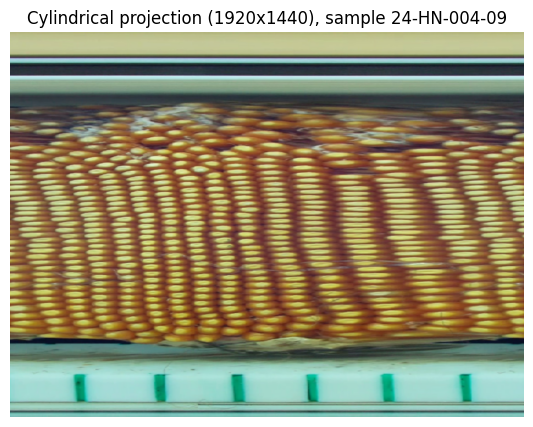

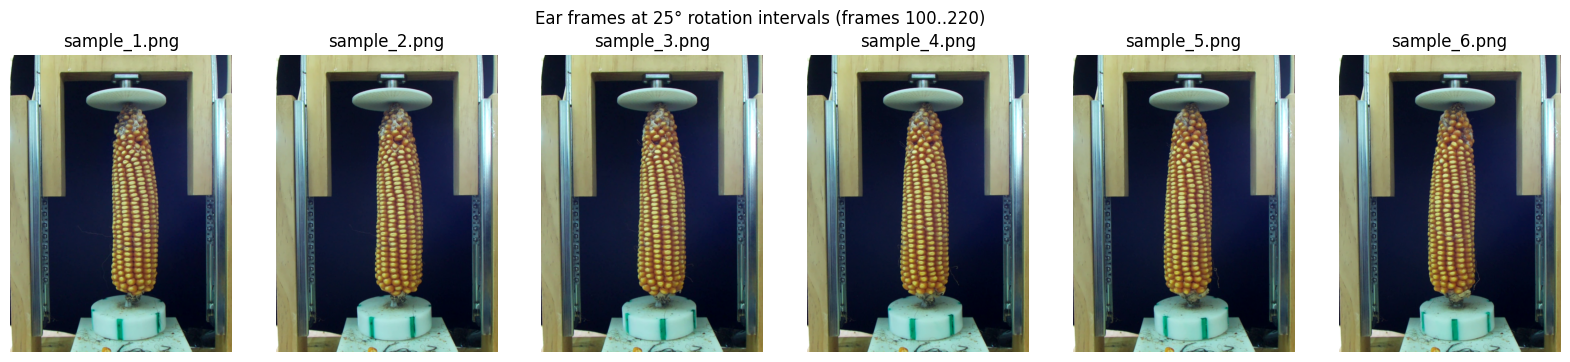

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))
proj = cv.imread(f'{WORK}/projection/sample.png')
ax.imshow(cv.cvtColor(proj, cv.COLOR_BGR2RGB))
ax.set_title('Cylindrical projection (1920x1440), sample 24-HN-004-09')
ax.axis('off')
plt.show()

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for ax_i, name in zip(axes, sorted(os.listdir(f'{WORK}/ear'))):
    img = cv.imread(f'{WORK}/ear/{name}')
    ax_i.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax_i.set_title(name)
    ax_i.axis('off')
plt.suptitle('Ear frames at 25° rotation intervals (frames 100..220)')
plt.show()

## 6. YOLOv11-seg inference — projection kernels and ear mask

Author README commands, run through the ultralytics Python API with the **same parameters**:

- projection: `conf=0.25, iou=0.4, imgsz=1600, max_det=1000, retina_masks=True, save_txt=True` (paper's own CLI uses `device=cpu`; we use the detected device for speed)
- ear (6 images): `conf=0.5, imgsz=640, max_det=1, retina_masks=True, save_txt=True`

Output: normalized polygon label files (`labels/*.txt`), one line per kernel / one for the ear.

**日本語:** 著者のREADMEと同一パラメータでYOLOv11-seg推論を実行します（投影画像：conf 0.25・imgsz 1600・max_det 1000、穂画像：conf 0.5・imgsz 640・max_det 1）。出力は正規化ポリゴンのラベルTXTです。

In [ ]:
from ultralytics import YOLO
import time

t0 = time.time()
proj_model = YOLO(f'{WORK}/models/Projection.pt')
proj_results = proj_model.predict(
    source=f'{WORK}/projection/', conf=0.25, iou=0.4, imgsz=1600,
    max_det=1000, retina_masks=True, save_txt=True, device=device,
    project=f'{WORK}/output', name='projection', exist_ok=True,
    verbose=False)
n_kernels = sum(len(r.boxes) for r in proj_results)
print(f'projection: {n_kernels} kernel masks in {round(time.time()-t0,1)} s')

t0 = time.time()
ear_model = YOLO(f'{WORK}/models/Ear.pt')
ear_results = ear_model.predict(
    source=f'{WORK}/ear/', conf=0.5, imgsz=640, max_det=1,
    retina_masks=True, save_txt=True, device=device,
    project=f'{WORK}/output', name='ear', exist_ok=True, verbose=False)
print(f'ear: {len(ear_results)} images, {sum(len(r.boxes) for r in ear_results)} ear masks in {round(time.time()-t0,1)} s')

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


Results saved to /content/openear/output/projection
1 label saved to /content/openear/output/projection/labels


projection: 560 kernel masks in 33.4 s


Results saved to /content/openear/output/ear
6 labels saved to /content/openear/output/ear/labels


ear: 6 images, 6 ear masks in 17.6 s


### Check the segmentation label files

Input: YOLO outputs from the projection and six ear images. This cell confirms that both expected label sets exist and previews a short ear-mask label line before measurement.

**日本語:** 投影画像と穂画像に対するYOLOのラベル出力が存在するか確認し、形質計算の前に穂マスクのラベルを短く表示します。

In [ ]:
# Confirm both expected model outputs exist before measuring traits.
import glob
proj_labels = glob.glob(f'{WORK}/output/projection/labels/*.txt')
ear_labels = glob.glob(f'{WORK}/output/ear/labels/*.txt')
if not proj_labels or not ear_labels:
    raise FileNotFoundError('YOLO label files are missing; trait extraction cannot proceed.')
print('projection label files:', len(proj_labels), '| ear label files:', len(ear_labels))
for path in ear_labels[:2]:
    print(path, '->', open(path).read()[:120].strip(), '...')

projection label files: 1 | ear label files: 6
/content/openear/output/ear/labels/sample_4.txt -> 0 0.523321 0.163889 0.521455 0.165278 0.521455 0.165972 0.522388 0.166667 0.522388 0.170139 0.523321 0.170833 0.523321 0 ...
/content/openear/output/ear/labels/sample_3.txt -> 0 0.525187 0.170139 0.526119 0.170833 0.526119 0.178472 0.524254 0.179861 0.524254 0.180556 0.522388 0.181944 0.521455 0 ...


## 7. Trait extraction from segmentation output (author code, verbatim logic)

Author `CLI/3_Model_output_analysis.py`, copied verbatim (module-level tkinter/import structure replaced by plain imports; behaviour unchanged):

- **KN** — kernel count in the central 91% of the projection width (`KN_range=0.91`), fractional overlap per kernel summed.
- **KRN** — 200 horizontal scan intervals; mode of doubled row counts (rounded to even). Filtered to central kernels, trimming 1/16 at both vertical ends.
- **KNpR** — KN // KRN.
- **KT** — mean vertical kernel spacing × KRN × scale × image height.
- **EL, ED** — min-area rect of the ear polygon; ED is the length of the rect's transverse cutting line inside the polygon.
- **EV** — cone/cylinder approximation: 20 horizontal slices, per-slice disc volumes.
- **TKA→TKW, EW, KW** — empirical calibrations from the paper: `EW = EV×0.65 + 35.86`, `TKW = TKA×0.58 + 66.84`, `KW = π·ED/KRN`; `scale_ratio = 2/100` cm/px (20 mm ↔ 100 px calibration marker).

**日本語:** 著者の `3_Model_output_analysis.py` の関数群をそのまま用いて10形質を算出します（中心91%の粒数、200区間の列数ヒストグラム、20分割の容積近似、論文の較正式 EW=EV×0.65+35.86、TKW=TKA×0.58+66.84 など）。

In [ ]:
import numpy as np, cv2 as cv, math, glob, os
from shapely.geometry import LineString, Polygon

# ---- author constants (verbatim) ----
scale_ratio = 2 / 100          # cm per pixel (20 mm calibration marker <-> 100 px)
image_height = 1440
image_width = 1072             # un-projection frame width used for ear polygon coords
projection_image_width = 1920
KN_range = 0.91
MAX_LEN = math.hypot(image_width, image_height)
start_index = (1 - KN_range) / 2
end_index = (1 + KN_range) / 2

# ---- author functions (verbatim) ----
def polygon_to_bbox(polygon):
    x_coords, y_coords = zip(*polygon)
    min_x, max_x = min(x_coords), max(x_coords)
    min_y, max_y = min(y_coords), max(y_coords)
    w = round(max_x - min_x, 7)
    h = round(max_y - min_y, 7)
    polygon = np.array(polygon, dtype=np.float32)
    area = Polygon(polygon).area
    return min_x, min_y, max_x, max_y, w, h, area

def pre_process_projection_label_file(projection_label_file_path):
    with open(projection_label_file_path, 'r') as infile:
        lines = infile.read().splitlines()
    bounding_boxes_data = []
    i = 0
    for line in lines:
        try:
            data = line.split()
            category = data[0]
            polygon = []
            for i in range(1, len(data), 2):
                x = float(data[i])
                y = float(data[i + 1])
                polygon.append((x, y))
            bbox = tuple(polygon_to_bbox(polygon))
            i = i + 1
            bounding_boxes_data.append(bbox)
        except:
            i = i + 1
            continue
    return bounding_boxes_data

def pre_process_ear_label_file(ear_file_path):
    polygon = []
    with open(ear_file_path, 'r') as file:
        data = file.readline().split()
        category = data[0]
        for i in range(1, len(data), 2):
            x = float(data[i]) * image_width
            y = float(data[i + 1]) * image_height
            polygon.append((x, y))
    polygon = np.array(polygon, dtype=np.float32)
    return polygon

def filter_regular_kernels(bboxes_data, start_index, end_index):
    bboxes_data = [bbox for bbox in bboxes_data
                   if start_index < (bbox[0] + bbox[2]) / 2 < end_index]
    bboxes_data.sort(key=lambda x: x[3])
    v_start_index = int(len(bboxes_data) / 16)
    v_end_index = int(len(bboxes_data) * 15 / 16)
    return bboxes_data[v_start_index:v_end_index]

def calculate_kernel_number(bboxes_data, start_index, end_index):
    kernel_number = 0.0
    for bbox in bboxes_data:
        min_x = bbox[0]
        max_x = bbox[2]
        w = bbox[4]
        if w <= 0:
            continue
        overlap_start = max(min_x, start_index)
        overlap_end = min(max_x, end_index)
        overlap_len = max(0.0, overlap_end - overlap_start)
        ratio = overlap_len / w
        kernel_number += ratio
    return int(kernel_number)

def calculate_kernel_row_number(bboxes_data, start_index, end_index):
    if start_index >= end_index:
        start_index, end_index = 0.5, 0.5
    bboxes_data = filter_regular_kernels(bboxes_data, start_index, end_index)
    if not bboxes_data:
        return 'NA'
    ymin_values = [bbox[1] for bbox in bboxes_data]
    ymax_values = [bbox[3] for bbox in bboxes_data]
    LOW = min(ymin_values)
    HIGH = max(ymax_values)
    num_intervals = 200
    step_size = (HIGH - LOW) / num_intervals
    row_counts = []
    for i in range(num_intervals):
        threshold = LOW + i * step_size
        row_bbox_count = sum(1 for bbox in bboxes_data if bbox[1] < threshold < bbox[3])
        raw_row_count = (row_bbox_count + 1) // 2 * 2
        row_counts.append(raw_row_count)
    kernel_row_number = round(max(set(row_counts), key=row_counts.count), 0)
    return kernel_row_number

def calculate_kernel_temp_value(bboxes_data, start_index, end_index):
    bboxes_data = filter_regular_kernels(bboxes_data, start_index, end_index)
    if not bboxes_data:
        return ''
    ymin_values = [bbox[1] for bbox in bboxes_data]
    ymax_values = [bbox[3] for bbox in bboxes_data]
    LOW = min(ymin_values)
    HIGH = max(ymax_values)
    kernels_area_height = HIGH - LOW
    inside_kernel_number = len(bboxes_data)
    kernel_temp_value = kernels_area_height / inside_kernel_number
    return kernel_temp_value

def calculate_thousand_kernel_area_temp_value(bboxes_data, start_index, end_index):
    filtered_bboxes_data = filter_regular_kernels(bboxes_data, start_index, end_index)
    if not bboxes_data:
        return ''
    area_sum = 0
    for bbox in filtered_bboxes_data:
        area_sum += bbox[6]
    filtered_kernel_number = len(bboxes_data)
    thousand_kernel_area_temp_value = area_sum / filtered_kernel_number * 1000
    return thousand_kernel_area_temp_value

def create_cutting_line(cx, cy, theta, l, w):
    if l >= w:
        rad = np.deg2rad(-theta)
        dx = np.sin(rad) * MAX_LEN
        dy = np.cos(rad) * MAX_LEN
    else:
        rad = np.deg2rad(theta)
        dx = np.cos(rad) * MAX_LEN
        dy = np.sin(rad) * MAX_LEN
    line = LineString([(cx - dx, cy - dy), (cx + dx, cy + dy)])
    return line

def calculate_ear_length_diameter(polygon):
    (cx, cy), (l, w), theta = cv.minAreaRect(polygon)
    polygon_shp = Polygon(polygon)
    cutting_line = create_cutting_line(cx, cy, theta, l, w)
    intersection_line = cutting_line.intersection(polygon_shp)
    ear_length = max(l, w) * scale_ratio
    ear_diameter = intersection_line.length * scale_ratio
    return ear_length, ear_diameter

def find_intersection_distances(polygon):
    num_lines = 20
    intersection_distances = []
    _, min_y, _, max_y, _, h, _ = polygon_to_bbox(polygon)
    interval_h = h / num_lines
    polygon_shp = Polygon(polygon)
    for i in range(0, num_lines):
        y = i * interval_h + min_y
        line = LineString([(0, y), (image_width, y)])
        intersection_line = line.intersection(polygon_shp)
        if intersection_line.is_empty:
            continue
        if intersection_line.geom_type == 'LineString':
            intersection_distances.append(intersection_line.length)
        elif intersection_line.geom_type == 'MultiLineString':
            for part in intersection_line.geoms:
                intersection_distances.append(part.length)
    return intersection_distances, interval_h

def calculate_ear_volume(polygon):
    distances, interval_h = find_intersection_distances(polygon)
    h = interval_h * scale_ratio
    ear_volume = 0
    for distance in distances:
        radius = distance / 2 * scale_ratio
        ear_volume += math.pi * radius ** 2 * h
    return ear_volume

def process_projection_file(file_path, start_index, end_index):
    bounding_boxes_data = pre_process_projection_label_file(file_path)
    kernel_number = calculate_kernel_number(bounding_boxes_data, start_index, end_index)
    kernel_row_number = calculate_kernel_row_number(bounding_boxes_data,
                                                    start_index + 0.035, end_index - 0.035)
    try:
        kernel_number_per_row = kernel_number // kernel_row_number
    except:
        kernel_number_per_row = "NA"
    kernel_temp_value = calculate_kernel_temp_value(bounding_boxes_data, start_index, end_index)
    try:
        kernel_thickness = kernel_temp_value * kernel_row_number * scale_ratio * image_height
    except:
        kernel_thickness = 'NA'
    thousand_kernel_area_temp_value = calculate_thousand_kernel_area_temp_value(bounding_boxes_data, start_index, end_index)
    return kernel_number, kernel_row_number, kernel_number_per_row, kernel_thickness, thousand_kernel_area_temp_value

def process_ear_file(file_path):
    polygon = pre_process_ear_label_file(file_path)
    ear_length, ear_diameter = calculate_ear_length_diameter(polygon)
    ear_volume = calculate_ear_volume(polygon)
    return ear_length, ear_diameter, ear_volume

print('author trait functions defined')

author trait functions defined


### Calculate the ten reported traits

This applies the authors’ supplied geometric calculations and calibrations to the kernel and ear polygons. Input: the verified YOLO label files; output: a one-row table and CSV under /content/openear.

**日本語:** YOLOの粒・穂ポリゴンに著者の幾何計算と較正式を適用し、10形質の1行テーブルとCSVを/content/openearに出力します。

In [ ]:
# Apply the author pipeline to the one sample; same medians and calibrations as the author main().
import pandas as pd

label = 'sample'
projection_label_file = glob.glob(f'{WORK}/output/projection/labels/{label}*.txt')[0]
ear_label_files = sorted(glob.glob(f'{WORK}/output/ear/labels/{label}_*.txt'))
if not ear_label_files:
    raise FileNotFoundError('No ear masks were produced for trait extraction.')
print('kernel polygons:', len(open(projection_label_file).read().splitlines()),
      '| ear label files:', len(ear_label_files))

kernel_number, kernel_row_number, kernel_number_per_row, kernel_thickness, tka_temp = \
    process_projection_file(projection_label_file, start_index, end_index)

ear_lengths, ear_diameters, ear_volumes = [], [], []
for ef in ear_label_files:
    try:
        el, ed, ev = process_ear_file(ef)
        ear_lengths.append(el)
        ear_diameters.append(ed)
        ear_volumes.append(ev)
    except Exception as e:
        print('Error on', ef, '->', e)

ear_length = round(np.median(np.array(ear_lengths)), 2)
ear_diameter = round(np.median(np.array(ear_diameters)), 2)
ear_volume = round(np.median(np.array(ear_volumes)), 2)

try:
    x_scale_ratio = ear_diameter * math.pi / (end_index - start_index) * projection_image_width
    thousand_kernel_area = tka_temp * x_scale_ratio * scale_ratio
    thousand_kernel_weight = round((thousand_kernel_area * 0.58 + 66.84), 2)
except:
    thousand_kernel_weight = 'NA'
try:
    ear_weight = round((ear_volume * 0.65 + 35.86), 2)
except:
    ear_weight = "NA"
try:
    kernel_width = round(ear_diameter * math.pi / kernel_row_number, 3)
except:
    kernel_width = 'NA'
try:
    kernel_thickness = round(kernel_thickness, 3)
except:
    kernel_thickness = 'NA'

results = pd.DataFrame([{
    'Label': label, 'Ear_Length_cm': ear_length, 'Ear_Diameter_cm': ear_diameter,
    'Ear_Volume_cm3': ear_volume, 'Ear_Weight_g': ear_weight,
    'Kernel_Number': kernel_number, 'Kernel_Row_Number': kernel_row_number,
    'Kernel_Number_per_Row': kernel_number_per_row, 'Kernel_Thickness_cm': kernel_thickness,
    'Kernel_Width_cm': kernel_width, 'Thousand_Kernel_Weight_g': thousand_kernel_weight}])
results.to_csv(f'{WORK}/ear_phenotyping.csv', index=False)
results

kernel polygons: 560 | ear label files: 6


,Label,Ear_Length_cm,Ear_Diameter_cm,Ear_Volume_cm3,Ear_Weight_g,Kernel_Number,Kernel_Row_Number,Kernel_Number_per_Row,Kernel_Thickness_cm,Kernel_Width_cm,Thousand_Kernel_Weight_g
0,sample,18.68,4.42,236.220001,189.399994,489,16,30,0.556,0.868,322.4


## 8. CNN quality control (author `.h5` models)

The author pipeline classifies each projection (grayscale 640×640) with two Keras CNNs from the repository:

1. **Developmental status** — class 0 → all traits become `NA` (ear too poorly developed).
2. **Kernel-row visibility** — class 0 → kernel-row-derived traits (columns 7–11) become `NA`.

Loaded with Colab TensorFlow using `compile=False`; training losses are not needed for inference.

**日本語:** 著者リポジトリ同梱の2つのCNNで品質チェックを行い、発育不良（クラス0）なら全形質を `NA`、粒列が見えないなら粒列由来の形質を `NA` にします。

In [ ]:
import tensorflow as tf
print('tensorflow', tf.__version__)
model1 = tf.keras.models.load_model(f'{WORK}/models/1_Developmental_Status_Assesment.h5', compile=False)
model2 = tf.keras.models.load_model(f'{WORK}/models/2_Kernel_Row_Visibility_Assesment.h5', compile=False)

img = cv.imread(f'{WORK}/projection/{label}.png', cv.IMREAD_GRAYSCALE)
x = np.expand_dims(np.expand_dims(cv.resize(img, (640, 640)), axis=-1), axis=0)  # author preprocessing

phenotype_prediction = int(np.argmax(model1.predict(x, verbose=0)))
kernel_row_number_prediction = int(np.argmax(model2.predict(x, verbose=0)))
print('developmental status class:', phenotype_prediction,
      '| kernel-row visibility class:', kernel_row_number_prediction)

if phenotype_prediction == 0:
    print('QC result: developmental status class 0 -> ALL traits set to NA (author rule).')
    results.loc[:, results.columns != 'Label'] = 'NA'
elif kernel_row_number_prediction == 0:
    print('QC result: kernel-row visibility class 0 -> row-derived traits set to NA (author rule).')
    for colname in ['Kernel_Row_Number', 'Kernel_Number_per_Row',
                    'Kernel_Thickness_cm', 'Kernel_Width_cm', 'Thousand_Kernel_Weight_g']:
        results[colname] = 'NA'
else:
    print('QC result: both classes nonzero -> all traits retained (author rule).')

results.to_csv(f'{WORK}/ear_phenotyping.csv', index=False)
results

tensorflow 2.20.0


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


developmental status class: 1 | kernel-row visibility class: 1
QC result: both classes nonzero -> all traits retained (author rule).


,Label,Ear_Length_cm,Ear_Diameter_cm,Ear_Volume_cm3,Ear_Weight_g,Kernel_Number,Kernel_Row_Number,Kernel_Number_per_Row,Kernel_Thickness_cm,Kernel_Width_cm,Thousand_Kernel_Weight_g
0,sample,18.68,4.42,236.220001,189.399994,489,16,30,0.556,0.868,322.4


## 9. Visualization: detected kernels and ear mask on the projection

Overlay of what the models actually predicted (kernels in one colour per instance, ear outline) — an additional visualization created for this notebook, not an author figure.

**日本語:** 投影画像に検出した粒マスクと穂マスクを重ねて表示します（本ノートブック用の追加可視化であり、論文の図ではありません）。

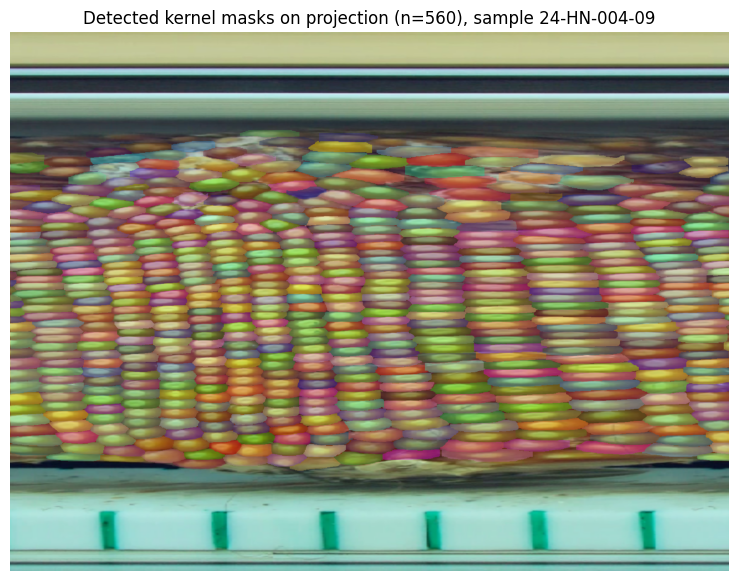

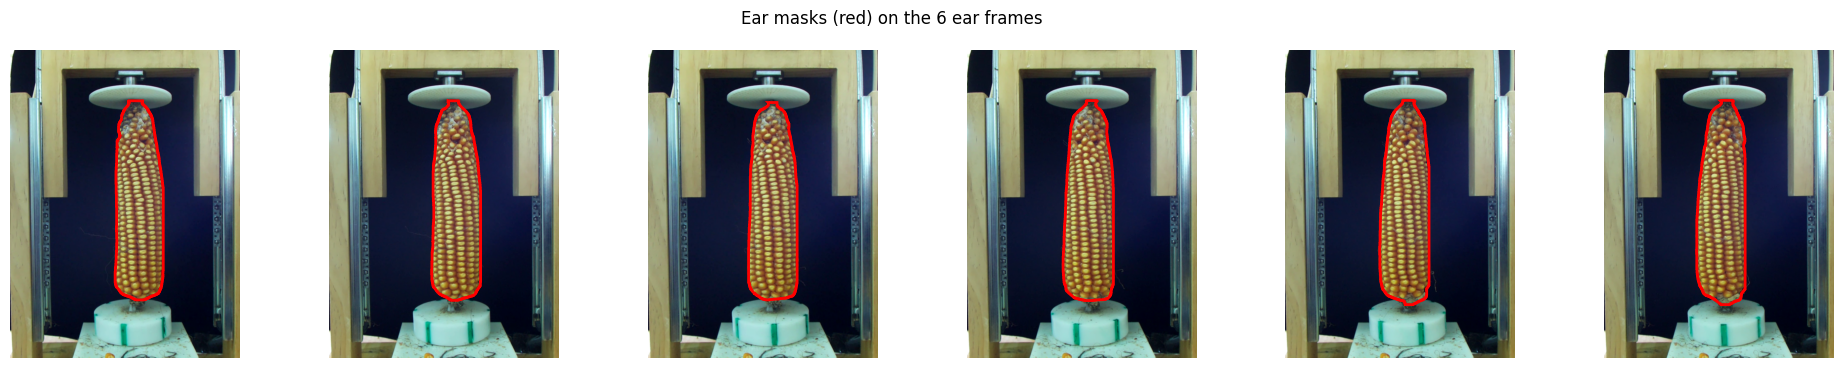

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import numpy as np, cv2 as cv

proj_img = cv.cvtColor(cv.imread(f'{WORK}/projection/{label}.png'), cv.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(18, 7))
ax.imshow(proj_img)

r = proj_results[0]
masks = r.masks
if masks is not None:
    rng = np.random.default_rng(0)
    overlay = proj_img.copy()
    for i, poly in enumerate(masks.xyn):
        pts = np.asarray(poly) * np.array([proj_img.shape[1], proj_img.shape[0]])
        color = rng.random(3)
        overlay = cv.fillPoly(overlay, pts.astype(np.int32)[np.newaxis], (int(color[0]*255), int(color[1]*255), int(color[2]*255)))
    ax.imshow(overlay, alpha=0.35)

er = ear_results[0]
if er.masks is not None:
    for poly in er.masks.xyn:
        pass  # ear masks belong to ear-frame images, drawn below

ax.set_title(f'Detected kernel masks on projection (n={n_kernels}), sample 24-HN-004-09')
ax.axis('off')
plt.show()

fig, axes = plt.subplots(1, len(ear_results), figsize=(4 * len(ear_results), 4))
axes = np.atleast_1d(axes)
for ax_i, res in zip(axes, ear_results):
    img = cv.cvtColor(res.orig_img, cv.COLOR_BGR2RGB)
    ax_i.imshow(img)
    if res.masks is not None:
        for poly in res.masks.xyn:
            pts = np.asarray(poly) * np.array([img.shape[1], img.shape[0]])
            ax_i.add_patch(MplPolygon(pts, closed=True, fill=False, edgecolor='red', linewidth=2))
    ax_i.axis('off')
plt.suptitle('Ear masks (red) on the 6 ear frames')
plt.show()

## 10. Interpretation, relation to the paper, and limitations

**Demonstration scope:** This notebook is designed to process one author-provided video through video correction, cylindrical projection, the released YOLOv11-segmentation weights, the authors’ trait-extraction logic, and CNN quality control. The validated outputs show the computed trait table and visual overlays for the selected video. Read the actual cell outputs to see which stages completed.

**What it does not establish:** A single video does not verify dataset-level accuracy, the paper’s manual-measurement comparison, sensitivity analysis, or training. Prediction quality depends on this sample’s capture conditions. The paper’s GUI allows manual boundary and row corrections; this notebook does not perform them. CNN QC classes are not independently evaluated here.

**Adaptations:** ImageMagick pixel operations use OpenCV/NumPy equivalents; inference calls the Ultralytics Python API with the README parameters; the notebook first tries a bounded Figshare range read for one archive member and downloads the full 1.52 GB archive only if the server does not support ranges. All data and model downloads occur in this Colab runtime.

**日本語:** 本ノートブックは著者提供の動画1本を、画像補正、円筒投影、YOLOv11推論、著者の形質計算、CNN品質判定まで処理する設計です。完了した工程と形質表・可視化は実際のセル出力で確認してください。1本の動画だけでは論文全体の精度、手動測定との比較、感度分析、学習を検証できません。GUIによる手動補正も行いません。

**References**
- Paper: *OpenEar: an ultra-affordable, high-throughput, and accurate maize ear phenotyping system*, Plant Methods (2026). doi:10.1186/s13007-026-01504-x (PMC12977455)
- Code: github.com/Chimaco37/OpenEar @ 1a2a5716 (Apache-2.0) — CLI/2_Video_processing.py, CLI/3_Model_output_analysis.py, models/image_process/camera_functions.py
- Weights and sample data: Figshare 10.6084/m9.figshare.29115983.v3 and 10.6084/m9.figshare.26283013.v3 (CC BY 4.0). The notebook queries the official [Figshare API v2](https://docs.figshare.com/v2/) inside Colab and downloads from each record’s returned public file URL.